### 서울시 자치구별 75세 이상 인구 대비 요양시설 정원

본 분석은 '초고령 사회, 서울의 의료·돌봄 인프라는 어디에 더 필요한가?'에서 서울시 자치구별 75세 이상 인구 대비 요양시설 정원을 계산하기 위해 작성되었다.

### 1. 분석 기준

- 시설 기준: 국민건강보험공단 장기요양기관 시설별 현황(2024-07-16)
- 인구 기준: 행정안전부 주민등록 인구통계(2024-07-31)
- 중증 수요 기준: 국민건강보험공단 노인장기요양보험 등급판정 현황(2024-07-31)
- 분석 단위: 서울특별시 25개 자치구
- 주 지표: `입소 정원 ÷ 75세 이상 주민등록인구 × 1,000`
- 보조 지표
  - 잔여정원: `입소 정원 − 현원`
  - 1,000명당 잔여정원: `잔여정원 ÷ 75세 이상 주민등록인구 × 1,000`
  - 가동률: `현원 ÷ 입소 정원`
  - 잔여정원 비율: `잔여정원 ÷ 장기요양 1~2등급 인정자 수 × 100` (한국은행 시군구 분석과 동일한 정의, 6절)

보고서의 전국 비교는 잔여정원(빈자리)을 기준으로 서울이 포화 상태임을 보였다. 자치구 비교에서는 구조적인 공급량인 정원을 주 지표로 쓰고, 잔여정원과 가동률로 '정원이 적은 곳은 수요도 적은 것 아닌가'라는 반론을 점검한다. 자치구별 잔여정원은 0~207석으로 규모가 작아 몇 명의 입·퇴소에도 순위가 크게 흔들리고, 최솟값이 0이라 배수 비교가 성립하지 않으므로 주 지표로는 쓰지 않는다. 다만 전국 비교와 지표가 달라 논지가 끊긴다는 문제가 남으므로, 6절에서 전국 비교와 같은 형태의 지표(수요 대비 잔여정원 비율)로 자치구를 다시 배열해 두 비교를 잇는다.

`요양시설 정원`의 경우 자료로 `assets/국민건강보험공단_장기요양기관 시설별 현황_20240716.xlsx`를 이용하였으며 다음 기관을 포함한다.

1. 노인요양시설(A01)
2. 노인전문요양시설(A02)
3. 노인요양시설(개정법)(A03)
4. 노인요양공동생활가정(A04)
5. 노인요양시설(단기보호 전환)(A05)

In [22]:
from io import BytesIO
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import requests
from IPython.display import display, Markdown

pd.set_option("display.max_rows", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

plt.rcParams["font.family"] = ["AppleGothic", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

ASSET_DIR = Path("assets")
FACILITY_FILE = next(ASSET_DIR.glob("*.xlsx"))
FACILITY_FILE.name

'국민건강보험공단_장기요양기관 시설별 현황_20240716.xlsx'

### 2. 요양시설 정원 집계

`일반현황`의 기관 소재지와 `입소인원`의 유형별 정원을 기관코드로 결합한 뒤 서울 25개 자치구로 집계한다.

In [23]:
general = pd.read_excel(
    FACILITY_FILE, sheet_name="일반현황", dtype={"장기요양기관코드": str}
)
capacity = pd.read_excel(
    FACILITY_FILE, sheet_name="입소인원", dtype={"장기요양기관코드": str}
)

general[["시도", "자치구"]] = general["시도 시군구 법정동명"].str.extract(
    r"^(\S+)\s+(\S+)"
)

RESIDENTIAL_CODES = ["A01", "A02", "A03", "A04", "A05"]
seoul_facilities = general.loc[
    general["시도"].eq("서울특별시"),
    ["장기요양기관코드", "장기요양기관이름", "자치구"],
]

residential = (
    capacity.loc[capacity["기관유형코드"].isin(RESIDENTIAL_CODES)]
    .merge(seoul_facilities, on="장기요양기관코드", how="inner", validate="many_to_one")
)

facility_by_gu = (
    residential.groupby("자치구", as_index=False)
    .agg(
        시설수=("장기요양기관코드", "nunique"),
        요양시설_정원=("정원", "sum"),
        요양시설_현원=("현원", "sum"),
    )
)

assert residential["장기요양기관코드"].notna().all()
assert facility_by_gu["자치구"].nunique() == 25

display(
    residential.groupby(["기관유형코드", "기관유형명"], as_index=False)
    .agg(시설수=("장기요양기관코드", "nunique"), 정원=("정원", "sum"))
)


,기관유형코드,기관유형명,시설수,정원
0,A03,노인요양시설(개정법),234,"13,766.00"
1,A04,노인요양공동생활가정,250,"2,221.00"


### 3. 75세 이상 주민등록인구 집계

행정안전부 공식 다운로드 엔드포인트에서 2024년 7월, 75세 이상, 전체 시군구 자료를 가져온다. 응답의 `연령구간인구수`는 75~79세부터 100세 이상까지의 합계다.

In [24]:
MOIS_PAGE = "https://jumin.mois.go.kr/ageStatMonth.do"
MOIS_DOWNLOAD = (
    "https://jumin.mois.go.kr/downloadCsvAge.do"
    "?searchYearMonth=month&xlsStats=2"
)

payload = {
    "sltOrgType": "1",
    "sltOrgLvl1": "A",
    "sltOrgLvl2": "",
    "gender": "gender",
    "sum": "sum",
    "sltUndefType": "",  # 전체: 거주자+거주불명자+재외국민, 외국인 제외
    "searchYearStart": "2024",
    "searchMonthStart": "07",
    "searchYearEnd": "2024",
    "searchMonthEnd": "07",
    "sltOrderType": "1",
    "sltOrderValue": "ASC",
    "sltArgTypes": "5",
    "sltArgTypeA": "75",
    "sltArgTypeB": "100",
    "category": "month",
}

session = requests.Session()
session.get(MOIS_PAGE, timeout=30).raise_for_status()
response = session.post(MOIS_DOWNLOAD, data=payload, timeout=120)
response.raise_for_status()
population_raw = pd.read_csv(BytesIO(response.content), encoding="cp949")

population = population_raw.loc[
    population_raw["행정구역"].str.match(r"^서울특별시\s+\S+구\s+\("),
    ["행정구역", "2024년07월_계_연령구간인구수"],
].copy()
population["자치구"] = population["행정구역"].str.extract(
    r"^서울특별시\s+(\S+구)"
)
population["75세이상_인구"] = pd.to_numeric(
    population["2024년07월_계_연령구간인구수"].astype(str).str.replace(",", "", regex=False)
)
population = population[["자치구", "75세이상_인구"]]

assert population["자치구"].nunique() == 25
assert population["75세이상_인구"].sum() == 729_748
population.head()


,자치구,75세이상_인구
1,종로구,13223
2,중구,11441
3,용산구,16985
4,성동구,21146
5,광진구,23391


### 4. 자치구별 공급 수준 계산

In [25]:
analysis = population.merge(facility_by_gu, on="자치구", how="left", validate="one_to_one")
assert len(analysis) == 25 and not analysis.isna().any().any()

analysis["75세이상_천명당_정원"] = (
    analysis["요양시설_정원"] / analysis["75세이상_인구"] * 1_000
)
analysis["정원대비_현원률"] = analysis["요양시설_현원"] / analysis["요양시설_정원"]
analysis["잔여정원"] = analysis["요양시설_정원"] - analysis["요양시설_현원"]
analysis["75세이상_천명당_잔여정원"] = (
    analysis["잔여정원"] / analysis["75세이상_인구"] * 1_000
)
analysis = analysis.sort_values("75세이상_천명당_정원", ascending=False).reset_index(drop=True)
analysis.insert(0, "순위", range(1, len(analysis) + 1))

seoul_rate = analysis["요양시설_정원"].sum() / analysis["75세이상_인구"].sum() * 1_000
seoul_occupancy = analysis["요양시설_현원"].sum() / analysis["요양시설_정원"].sum()
seoul_vacancy_rate = analysis["잔여정원"].sum() / analysis["75세이상_인구"].sum() * 1_000
highest = analysis.iloc[0]
lowest = analysis.iloc[-1]
gap = highest["75세이상_천명당_정원"] / lowest["75세이상_천명당_정원"]

headline = (
    f"실제로 75세 이상 인구 1,000명당 요양시설 정원은 "
    f"{highest['자치구']}가 {highest['75세이상_천명당_정원']:.1f}명인 반면 "
    f"{lowest['자치구']}는 {lowest['75세이상_천명당_정원']:.1f}명으로 "
    f"약 {gap:.1f}배 차이가 난다."
)
display(Markdown(f"### {headline}"))
display(
    analysis[["순위", "자치구", "75세이상_인구", "시설수", "요양시설_정원", "75세이상_천명당_정원", "정원대비_현원률", "잔여정원", "75세이상_천명당_잔여정원"]]
    .style.format({
        "75세이상_인구": "{:,.0f}",
        "시설수": "{:,.0f}",
        "요양시설_정원": "{:,.0f}",
        "75세이상_천명당_정원": "{:.1f}",
        "정원대비_현원률": "{:.1%}",
        "잔여정원": "{:,.0f}",
        "75세이상_천명당_잔여정원": "{:.2f}",
    })
    .background_gradient(subset=["75세이상_천명당_정원"], cmap="Blues")
    .hide(axis="index")
)


### 실제로 75세 이상 인구 1,000명당 요양시설 정원은 금천구가 40.8명인 반면 중구는 7.3명으로 약 5.6배 차이가 난다.

순위,자치구,75세이상_인구,시설수,요양시설_정원,75세이상_천명당_정원,정원대비_현원률,잔여정원,75세이상_천명당_잔여정원
1,금천구,"18,095",22,739,40.8,90.9%,67,3.70
2,도봉구,"30,170",53,"1,162",38.5,92.9%,83,2.75
3,중랑구,"32,216",49,"1,165",36.2,93.9%,71,2.20
4,구로구,"32,154",16,981,30.5,89.1%,107,3.33
5,종로구,"13,223",10,400,30.3,95.5%,18,1.36
6,강서구,"40,264",31,"1,213",30.1,89.2%,131,3.25
7,은평구,"41,074",23,"1,154",28.1,88.1%,137,3.34
8,강북구,"30,874",32,811,26.3,83.7%,132,4.28
9,노원구,"40,834",25,"1,044",25.6,80.2%,207,5.07
10,광진구,"23,391",19,588,25.1,96.6%,20,0.86


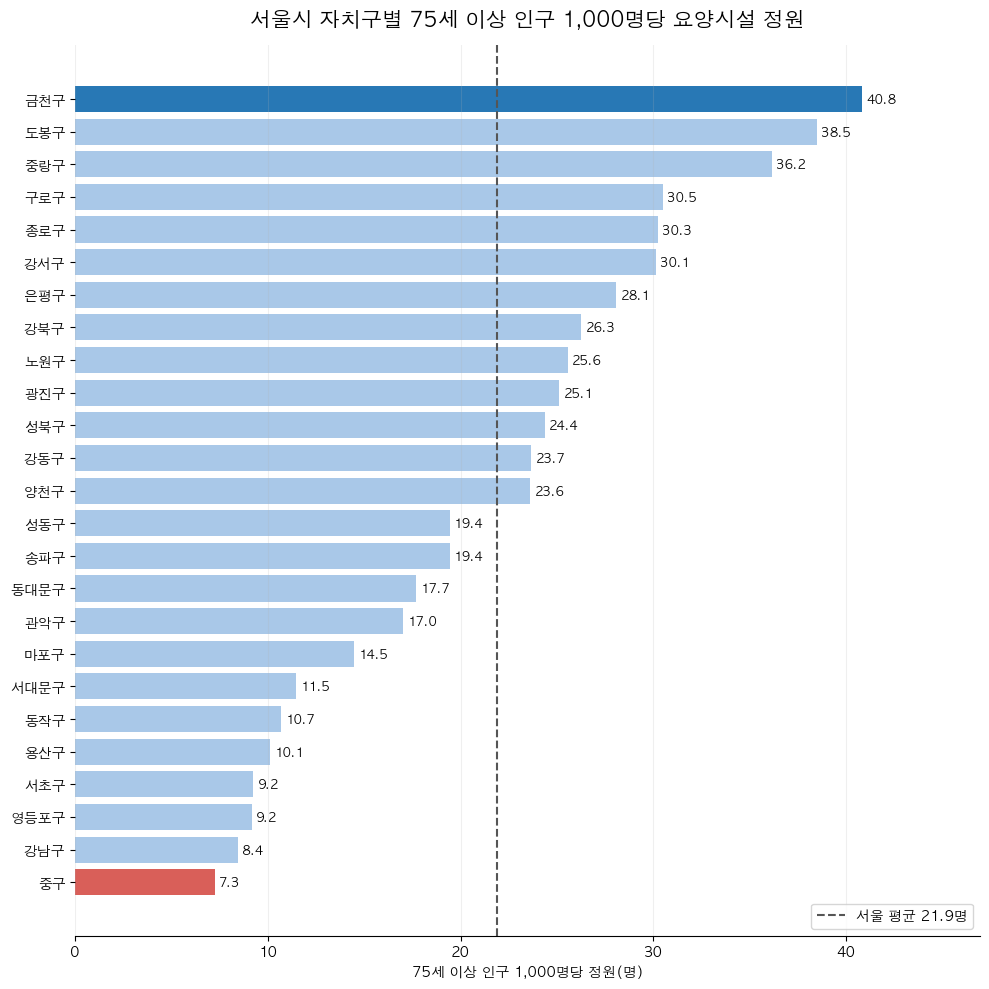

In [26]:
plot_data = analysis.sort_values("75세이상_천명당_정원", ascending=True)
colors = [
    "#D95F59" if gu == lowest["자치구"] else "#2878B5" if gu == highest["자치구"] else "#A9C8E8"
    for gu in plot_data["자치구"]
]

fig, ax = plt.subplots(figsize=(10, 10))
bars = ax.barh(plot_data["자치구"], plot_data["75세이상_천명당_정원"], color=colors)
ax.axvline(seoul_rate, color="#555555", linestyle="--", linewidth=1.5, label=f"서울 평균 {seoul_rate:.1f}명")
ax.bar_label(bars, labels=[f"{v:.1f}" for v in plot_data["75세이상_천명당_정원"]], padding=3, fontsize=9)
ax.set_title("서울시 자치구별 75세 이상 인구 1,000명당 요양시설 정원", fontsize=15, pad=14)
ax.set_xlabel("75세 이상 인구 1,000명당 정원(명)")
ax.set_ylabel("")
ax.set_xlim(0, plot_data["75세이상_천명당_정원"].max() * 1.15)
ax.grid(axis="x", alpha=0.2)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


### 5. 잔여정원·가동률로 본 공급 여유

정원이 적은 자치구가 단순히 수요가 적어서 시설이 적은 것이라면, 그곳의 시설에는 빈자리가 많아야 한다. 반대로 시설이 거의 가득 차 있다면 정원이 적은 것은 수요 부족이 아니라 공급 부족으로 볼 수 있다.

기준: 1,000명당 정원이 **서울 평균의 절반 미만**인 자치구를 '정원 하위 구'로 정의하고, 이들의 가동률과 1,000명당 잔여정원을 서울 평균과 비교한다.

In [27]:
low_supply = (
    analysis.loc[analysis["75세이상_천명당_정원"] < seoul_rate / 2]
    .sort_values("75세이상_천명당_정원")
    .reset_index(drop=True)
)
saturated = low_supply.loc[low_supply["정원대비_현원률"] > seoul_occupancy]
exceptions = low_supply.loc[low_supply["정원대비_현원률"] <= seoul_occupancy]

rank_corr = analysis["75세이상_천명당_정원"].corr(
    analysis["75세이상_천명당_잔여정원"], method="spearman"
)

display(Markdown(
    f"- 서울 평균: 1,000명당 정원 **{seoul_rate:.1f}명**, 가동률 **{seoul_occupancy:.1%}**, "
    f"1,000명당 잔여정원 **{seoul_vacancy_rate:.2f}명**\n"
    f"- 정원 하위 구(평균의 절반 = {seoul_rate / 2:.1f}명 미만): **{len(low_supply)}개 구**\n"
    f"- 1,000명당 정원과 1,000명당 잔여정원의 스피어만 순위상관: **{rank_corr:.2f}**"
))
display(
    low_supply[["자치구", "75세이상_천명당_정원", "요양시설_정원", "요양시설_현원", "정원대비_현원률", "잔여정원", "75세이상_천명당_잔여정원"]]
    .style.format({
        "75세이상_천명당_정원": "{:.1f}",
        "요양시설_정원": "{:,.0f}",
        "요양시설_현원": "{:,.0f}",
        "정원대비_현원률": "{:.1%}",
        "잔여정원": "{:,.0f}",
        "75세이상_천명당_잔여정원": "{:.2f}",
    })
    .hide(axis="index")
)

- 서울 평균: 1,000명당 정원 **21.9명**, 가동률 **90.8%**, 1,000명당 잔여정원 **2.01명**
- 정원 하위 구(평균의 절반 = 11.0명 미만): **6개 구**
- 1,000명당 정원과 1,000명당 잔여정원의 스피어만 순위상관: **0.75**

자치구,75세이상_천명당_정원,요양시설_정원,요양시설_현원,정원대비_현원률,잔여정원,75세이상_천명당_잔여정원
중구,7.3,83,81,97.6%,2,0.17
강남구,8.4,303,253,83.5%,50,1.39
영등포구,9.2,260,249,95.8%,11,0.39
서초구,9.2,254,245,96.5%,9,0.33
용산구,10.1,172,171,99.4%,1,0.06
동작구,10.7,328,315,96.0%,13,0.42


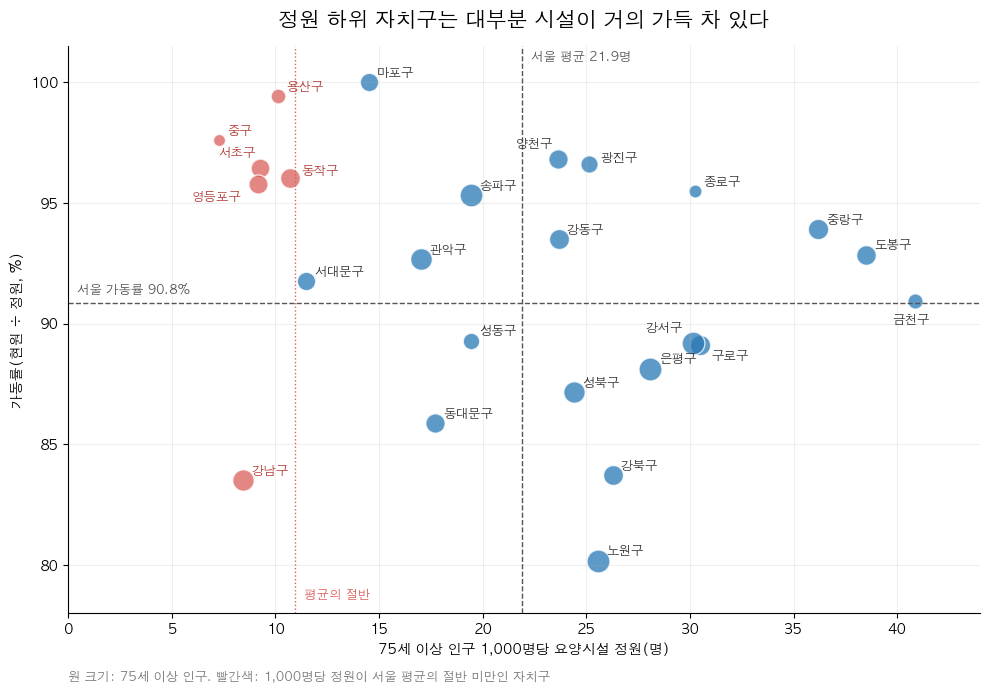

In [28]:
# 라벨 겹침 방지용 위치 조정
LABEL_OFFSET = {
    "서초구": (-30, 8), "영등포구": (-48, -12), "동작구": (8, 2),
    "강서구": (-34, 8), "구로구": (8, -10), "양천구": (-30, 8),
    "광진구": (8, 2), "금천구": (-16, -16),
}
fig, ax = plt.subplots(figsize=(10, 7))
low_names = set(low_supply["자치구"])
for _, row in analysis.iterrows():
    is_low = row["자치구"] in low_names
    ax.scatter(
        row["75세이상_천명당_정원"], row["정원대비_현원률"] * 100,
        s=row["75세이상_인구"] / 150,
        color="#D95F59" if is_low else "#2878B5",
        alpha=0.75, edgecolor="white", linewidth=1,
    )
    ax.annotate(
        row["자치구"], (row["75세이상_천명당_정원"], row["정원대비_현원률"] * 100),
        xytext=LABEL_OFFSET.get(row["자치구"], (6, 4)), textcoords="offset points", fontsize=9,
        color="#B03A35" if is_low else "#333333",
    )
ax.axvline(seoul_rate, color="#555555", linestyle="--", linewidth=1)
ax.axvline(seoul_rate / 2, color="#D95F59", linestyle=":", linewidth=1)
ax.axhline(seoul_occupancy * 100, color="#555555", linestyle="--", linewidth=1)
ax.text(seoul_rate + 0.4, 100.9, f"서울 평균 {seoul_rate:.1f}명", fontsize=9, color="#555555")
ax.text(seoul_rate / 2 + 0.4, 78.6, "평균의 절반", fontsize=9, color="#D95F59")
ax.text(0.4, seoul_occupancy * 100 + 0.4, f"서울 가동률 {seoul_occupancy:.1%}", fontsize=9, color="#555555")
ax.set_title("정원 하위 자치구는 대부분 시설이 거의 가득 차 있다", fontsize=15, pad=14)
ax.set_xlabel("75세 이상 인구 1,000명당 요양시설 정원(명)")
ax.set_ylabel("가동률(현원 ÷ 정원, %)")
ax.set_xlim(0, 44)
ax.set_ylim(78, 101.5)
ax.grid(alpha=0.2)
ax.spines[["top", "right"]].set_visible(False)
ax.text(0, -0.12, "원 크기: 75세 이상 인구. 빨간색: 1,000명당 정원이 서울 평균의 절반 미만인 자치구",
        transform=ax.transAxes, fontsize=9, color="#777777")
plt.tight_layout()
plt.show()

In [29]:
def join_gu(names):
    return "·".join(names)

sat = saturated.sort_values("75세이상_천명당_정원")
supplement = (
    f"정원이 적은 지역이 수요가 적은 것도 아니다. "
    f"1,000명당 정원이 서울 평균의 절반에 못 미치는 {len(low_supply)}개 구 가운데 "
    f"{join_gu(sat['자치구'])}의 시설 가동률은 "
    f"{sat['정원대비_현원률'].min():.1%}~{sat['정원대비_현원률'].max():.1%}로, "
    f"75세 이상 1,000명당 남은 자리는 {sat['75세이상_천명당_잔여정원'].max():.2f}명 이하에 그친다"
    f"(서울 평균 {seoul_vacancy_rate:.2f}명)."
)
display(Markdown(f"> {supplement}"))
print(supplement)

> 정원이 적은 지역이 수요가 적은 것도 아니다. 1,000명당 정원이 서울 평균의 절반에 못 미치는 6개 구 가운데 중구·영등포구·서초구·용산구·동작구의 시설 가동률은 95.8%~99.4%로, 75세 이상 1,000명당 남은 자리는 0.42명 이하에 그친다(서울 평균 2.01명).

정원이 적은 지역이 수요가 적은 것도 아니다. 1,000명당 정원이 서울 평균의 절반에 못 미치는 6개 구 가운데 중구·영등포구·서초구·용산구·동작구의 시설 가동률은 95.8%~99.4%로, 75세 이상 1,000명당 남은 자리는 0.42명 이하에 그친다(서울 평균 2.01명).


### 6. 전국 비교와 같은 지표: 중증 수요 대비 잔여정원

전국 비교(한국은행 2026, 그림 2.23)는 `생애말기 고령인구수 대비 잔여정원 비율`을 썼고 서울은 3.4%로 17개 시도 중 가장 낮았다. 생애말기 고령인구는 **1년 후 질병으로 사망하는 65세 이상 인구**로 정의되는데, 사망원인과 연령을 교차한 시군구 단위 통계가 공표되지 않아 자치구별로는 계산할 수 없다. 같은 보고서도 시군구 단위 분석에서는 이를 대체했다.

> 생애말기 고령인구수는 시군구별 자료를 확보하기 어려웠다. 이에 따라 노인요양시설 잠재 수요 지표로서 장기요양 1∼2등급자수를 대신 활용하였다. — 한국은행(2026) 각주 35

따라서 본 절도 한국은행의 시군구 분석과 동일하게 장기요양 1~2등급 인정자 수를 중증 돌봄 수요의 대리지표로 삼는다. 장기요양 1등급자의 78.7%가 와상 상태이므로(2022년 장기요양실태조사) 요양시설 입소가 필요한 수요에 가장 가깝고, 한국은행이 지가–공급 관계를 추정한 공간패널모형(그림 3.2)의 종속변수와도 같은 지표다.

- 지표: `잔여정원 비율 = (정원 − 현원) ÷ 장기요양 1~2등급 인정자 수 × 100`
- 수요 자료: 국민건강보험공단 노인장기요양보험 등급판정 현황(2024-07-31), 전체 자격·전 연령 기준(65세 미만은 1~2등급자의 5.4%)

In [30]:
GRADE_FILE = ASSET_DIR / "국민건강보험공단_노인장기요양보험 등급판정 현황_20240731.csv"

grade_raw = pd.read_csv(GRADE_FILE, encoding="cp949")
grade_raw.columns = [c.strip() for c in grade_raw.columns]
for col in ["시도", "시군구"]:
    grade_raw[col] = grade_raw[col].astype(str).str.strip()
for col in ["1등급", "2등급"]:
    grade_raw[col] = pd.to_numeric(
        grade_raw[col].astype(str).str.replace(",", "", regex=False), errors="coerce"
    )
grade_raw["중증_1_2등급"] = grade_raw["1등급"] + grade_raw["2등급"]

severe_by_gu = (
    grade_raw.loc[grade_raw["시도"].eq("서울")]
    .groupby("시군구", as_index=False)["중증_1_2등급"]
    .sum()
    .rename(columns={"시군구": "자치구"})
)

assert severe_by_gu["자치구"].nunique() == 25

demand = analysis.merge(severe_by_gu, on="자치구", how="left", validate="one_to_one")
demand["잔여정원_비율"] = demand["잔여정원"] / demand["중증_1_2등급"] * 100
demand["중증_대비_정원"] = demand["요양시설_정원"] / demand["중증_1_2등급"] * 100
demand = demand.sort_values("잔여정원_비율").reset_index(drop=True)

seoul_vacancy_ratio = demand["잔여정원"].sum() / demand["중증_1_2등급"].sum() * 100
ratio_corr = demand["75세이상_천명당_정원"].corr(demand["잔여정원_비율"], method="spearman")

display(Markdown(
    f"- 서울 전체 잔여정원 비율: **{seoul_vacancy_ratio:.1f}%** "
    f"(잔여정원 {demand['잔여정원'].sum():,.0f}석 ÷ 1~2등급 {demand['중증_1_2등급'].sum():,.0f}명)\n"
    f"- 서울 평균보다 낮은 자치구: **{(demand['잔여정원_비율'] < seoul_vacancy_ratio).sum()}개 구**\n"
    f"- 1,000명당 정원과 잔여정원 비율의 스피어만 순위상관: **{ratio_corr:.2f}**"
))
display(
    demand[["자치구", "중증_1_2등급", "요양시설_정원", "요양시설_현원", "잔여정원", "잔여정원_비율", "중증_대비_정원", "75세이상_천명당_정원"]]
    .style.format({
        "중증_1_2등급": "{:,.0f}",
        "요양시설_정원": "{:,.0f}",
        "요양시설_현원": "{:,.0f}",
        "잔여정원": "{:,.0f}",
        "잔여정원_비율": "{:.1f}",
        "중증_대비_정원": "{:.1f}",
        "75세이상_천명당_정원": "{:.1f}",
    })
    .background_gradient(subset=["잔여정원_비율"], cmap="Blues_r")
    .hide(axis="index")
)

- 서울 전체 잔여정원 비율: **6.3%** (잔여정원 1,466석 ÷ 1~2등급 23,249명)
- 서울 평균보다 낮은 자치구: **15개 구**
- 1,000명당 정원과 잔여정원 비율의 스피어만 순위상관: **0.73**

자치구,중증_1_2등급,요양시설_정원,요양시설_현원,잔여정원,잔여정원_비율,중증_대비_정원,75세이상_천명당_정원
마포구,697,380,380,0,0.0,54.5,14.5
용산구,475,172,171,1,0.2,36.2,10.1
중구,256,83,81,2,0.8,32.4,7.3
서초구,923,254,245,9,1.0,27.5,9.2
영등포구,"1,008",260,249,11,1.1,25.8,9.2
동작구,733,328,315,13,1.8,44.7,10.7
양천구,904,691,669,22,2.4,76.4,23.6
송파구,"1,243",791,754,37,3.0,63.6,19.4
광진구,659,588,568,20,3.0,89.2,25.1
강남구,"1,394",303,253,50,3.6,21.7,8.4


In [31]:
# 같은 지표를 17개 시도에 적용해 전국 비교를 재현한다.
SIDO_ALIAS = {
    "서울특별시": "서울", "부산광역시": "부산", "대구광역시": "대구", "인천광역시": "인천",
    "광주광역시": "광주", "대전광역시": "대전", "울산광역시": "울산", "세종특별자치시": "세종",
    "경기도": "경기", "강원특별자치도": "강원", "충청북도": "충북", "충청남도": "충남",
    "전라북도": "전북", "전북특별자치도": "전북", "전라남도": "전남",
    "경상북도": "경북", "경상남도": "경남", "제주특별자치도": "제주",
}

national = (
    capacity.loc[capacity["기관유형코드"].isin(RESIDENTIAL_CODES)]
    .merge(
        general.assign(시도명=general["시도"].map(SIDO_ALIAS))[["장기요양기관코드", "시도명"]],
        on="장기요양기관코드", how="inner", validate="many_to_one",
    )
    .groupby("시도명", as_index=False)
    .agg(정원=("정원", "sum"), 현원=("현원", "sum"))
)

sido = (
    national.merge(
        grade_raw.groupby("시도", as_index=False)["중증_1_2등급"].sum(),
        left_on="시도명", right_on="시도", validate="one_to_one",
    )
    .assign(잔여정원=lambda d: d["정원"] - d["현원"])
)
sido["잔여정원_비율"] = sido["잔여정원"] / sido["중증_1_2등급"] * 100
sido = sido.sort_values("잔여정원_비율").reset_index(drop=True)

# 한국은행 그림 2.23(생애말기 고령인구 분모)과 순위 비교
BOK_2024 = {"서울": 3.4, "부산": 7.2, "대구": 9.3, "전북": 12.4, "경북": 15.8, "충북": 17.6}
check = sido.loc[sido["시도명"].isin(BOK_2024)].copy()
check["한국은행_생애말기_분모"] = check["시도명"].map(BOK_2024)
bok_corr = check["잔여정원_비율"].corr(check["한국은행_생애말기_분모"], method="spearman")

assert sido.iloc[0]["시도명"] == "서울"
display(Markdown(
    f"- 분모를 1~2등급자 수로 바꿔도 **서울이 17개 시도 중 최저**(한국은행 그림 2.23과 동일한 결론)\n"
    f"- 한국은행이 제시한 6개 시도 값과의 순위상관: **{bok_corr:.2f}** "
    f"(수준은 분모가 달라 직접 비교할 수 없고, 지역 간 순서만 비교한다)"
))
display(
    check[["시도명", "한국은행_생애말기_분모", "잔여정원_비율"]]
    .rename(columns={"한국은행_생애말기_분모": "한국은행(생애말기 고령인구 대비, %)", "잔여정원_비율": "본 분석(1~2등급자 대비, %)"})
    .style.format({"한국은행(생애말기 고령인구 대비, %)": "{:.1f}", "본 분석(1~2등급자 대비, %)": "{:.1f}"})
    .hide(axis="index")
)

- 분모를 1~2등급자 수로 바꿔도 **서울이 17개 시도 중 최저**(한국은행 그림 2.23과 동일한 결론)
- 한국은행이 제시한 6개 시도 값과의 순위상관: **0.83** (수준은 분모가 달라 직접 비교할 수 없고, 지역 간 순서만 비교한다)

시도명,"한국은행(생애말기 고령인구 대비, %)","본 분석(1~2등급자 대비, %)"
서울,3.4,6.3
부산,7.2,15.7
대구,9.3,18.7
충북,17.6,29.2
전북,12.4,38.0
경북,15.8,42.6


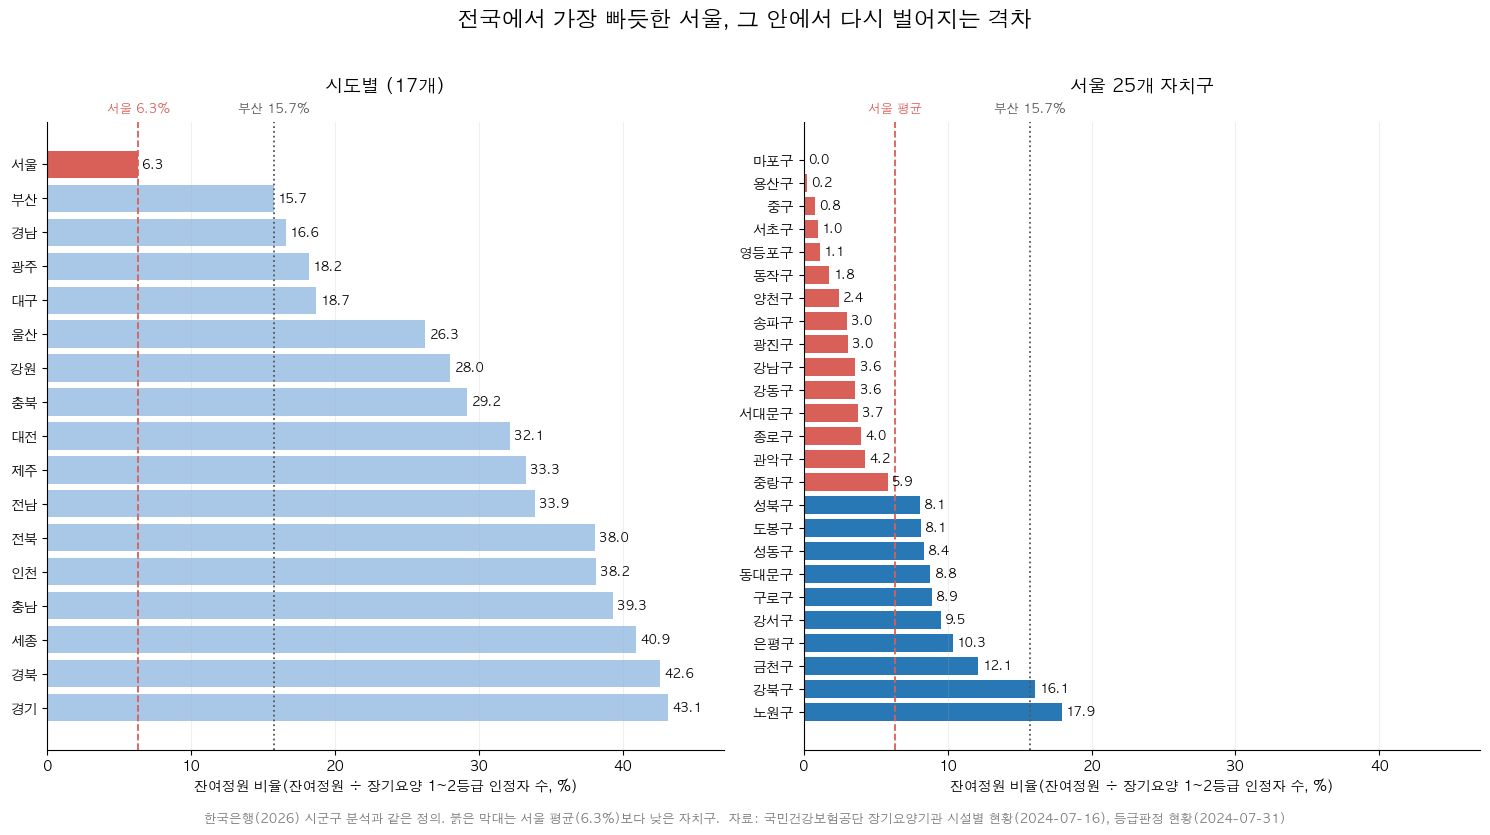

In [32]:
fig, (ax_sido, ax_gu) = plt.subplots(1, 2, figsize=(15, 8.5), sharex=True)

# (왼쪽) 시도별
sido_colors = ["#D95F59" if name == "서울" else "#A9C8E8" for name in sido["시도명"]]
bars_sido = ax_sido.barh(sido["시도명"], sido["잔여정원_비율"], color=sido_colors)
ax_sido.bar_label(bars_sido, labels=[f"{v:.1f}" for v in sido["잔여정원_비율"]], padding=3, fontsize=9)
ax_sido.set_title("시도별 (17개)", fontsize=13, pad=22)
ax_sido.invert_yaxis()

# (오른쪽) 서울 자치구별
gu_plot = demand.sort_values("잔여정원_비율")
gu_colors = ["#D95F59" if v < seoul_vacancy_ratio else "#2878B5" for v in gu_plot["잔여정원_비율"]]
bars_gu = ax_gu.barh(gu_plot["자치구"], gu_plot["잔여정원_비율"], color=gu_colors)
ax_gu.bar_label(bars_gu, labels=[f"{v:.1f}" for v in gu_plot["잔여정원_비율"]], padding=3, fontsize=9)
ax_gu.set_title("서울 25개 자치구", fontsize=13, pad=22)
ax_gu.invert_yaxis()

second_lowest = sido.iloc[1]
for ax, seoul_label in ((ax_sido, f"서울 {seoul_vacancy_ratio:.1f}%"), (ax_gu, "서울 평균")):
    ax.axvline(seoul_vacancy_ratio, color="#D95F59", linestyle="--", linewidth=1.3)
    ax.axvline(second_lowest["잔여정원_비율"], color="#555555", linestyle=":", linewidth=1.3)
    ax.set_xlabel("잔여정원 비율(잔여정원 ÷ 장기요양 1~2등급 인정자 수, %)")
    ax.set_xlim(0, 47)
    ax.grid(axis="x", alpha=0.2)
    ax.spines[["top", "right"]].set_visible(False)
    trans = ax.get_xaxis_transform()
    ax.text(seoul_vacancy_ratio, 1.012, seoul_label, transform=trans,
            ha="center", va="bottom", fontsize=9, color="#D95F59")
    ax.text(second_lowest["잔여정원_비율"], 1.012,
            f"{second_lowest['시도명']} {second_lowest['잔여정원_비율']:.1f}%", transform=trans,
            ha="center", va="bottom", fontsize=9, color="#555555")

fig.suptitle("전국에서 가장 빠듯한 서울, 그 안에서 다시 벌어지는 격차", fontsize=16, y=0.975)
fig.text(0.5, 0.018,
         "한국은행(2026) 시군구 분석과 같은 정의. 붉은 막대는 서울 평균(6.3%)보다 낮은 자치구."
         "  자료: 국민건강보험공단 장기요양기관 시설별 현황(2024-07-16), 등급판정 현황(2024-07-31)",
         ha="center", fontsize=9, color="#777777")
plt.tight_layout(rect=[0, 0.035, 1, 0.955])
plt.show()

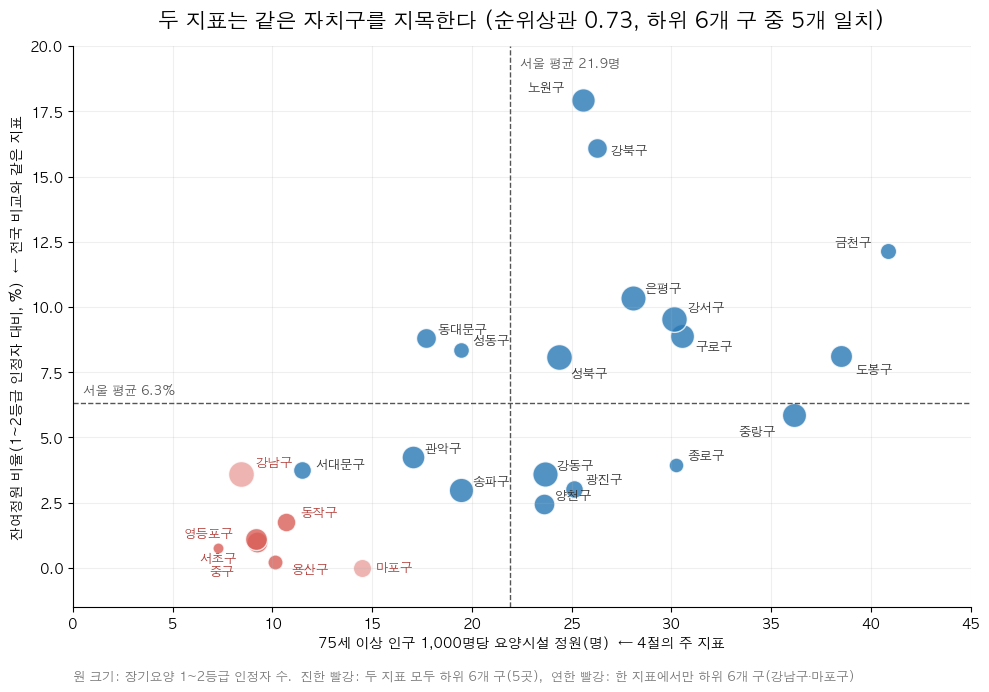

In [33]:
# 지표를 바꿔도 같은 지역이 지목되는지 확인한다.
low_by_ratio = set(demand.nsmallest(6, "잔여정원_비율")["자치구"])
low_by_capacity = set(demand.nsmallest(6, "75세이상_천명당_정원")["자치구"])
both_low = low_by_ratio & low_by_capacity
either_low = low_by_ratio ^ low_by_capacity

LABEL_OFFSET_2 = {
    "중구": (-6, -20), "강남구": (10, 6), "영등포구": (-52, 2), "서초구": (-42, -14),
    "용산구": (12, -8), "동작구": (10, 4), "서대문구": (10, 2), "마포구": (10, -2),
    "노원구": (-40, 6), "강북구": (10, -4), "금천구": (-38, 4), "도봉구": (10, -12),
    "중랑구": (-40, -14), "성북구": (8, -14), "강서구": (10, 6), "구로구": (10, -10),
}
fig, ax = plt.subplots(figsize=(10, 7))
for _, row in demand.iterrows():
    gu = row["자치구"]
    color = "#D95F59" if gu in both_low else "#E9A29E" if gu in either_low else "#2878B5"
    ax.scatter(
        row["75세이상_천명당_정원"], row["잔여정원_비율"], s=row["중증_1_2등급"] / 4,
        color=color, alpha=0.8, edgecolor="white", linewidth=1,
    )
    ax.annotate(
        gu, (row["75세이상_천명당_정원"], row["잔여정원_비율"]),
        xytext=LABEL_OFFSET_2.get(gu, (8, 4)), textcoords="offset points",
        fontsize=9, color="#B03A35" if gu in both_low | either_low else "#333333",
    )
ax.axhline(seoul_vacancy_ratio, color="#555555", linestyle="--", linewidth=1)
ax.axvline(seoul_rate, color="#555555", linestyle="--", linewidth=1)
ax.text(0.5, seoul_vacancy_ratio + 0.35, f"서울 평균 {seoul_vacancy_ratio:.1f}%", fontsize=9, color="#555555")
ax.text(seoul_rate + 0.5, 19.2, f"서울 평균 {seoul_rate:.1f}명", fontsize=9, color="#555555")
ax.set_title(
    f"두 지표는 같은 자치구를 지목한다 (순위상관 {ratio_corr:.2f}, 하위 6개 구 중 {len(both_low)}개 일치)",
    fontsize=15, pad=14,
)
ax.set_xlabel("75세 이상 인구 1,000명당 요양시설 정원(명)  ← 4절의 주 지표")
ax.set_ylabel("잔여정원 비율(1~2등급 인정자 대비, %)  ← 전국 비교와 같은 지표")
ax.set_xlim(0, 45)
ax.set_ylim(-1.5, 20)
ax.grid(alpha=0.2)
ax.spines[["top", "right"]].set_visible(False)
ax.text(0, -0.13,
        "원 크기: 장기요양 1~2등급 인정자 수.  진한 빨강: 두 지표 모두 하위 6개 구(5곳),  연한 빨강: 한 지표에서만 하위 6개 구(강남구·마포구)",
        transform=ax.transAxes, fontsize=9, color="#777777")
plt.tight_layout()
plt.show()

In [34]:
lowest5 = demand.nsmallest(5, "잔여정원_비율")
below_busan = (demand["잔여정원_비율"] < second_lowest["잔여정원_비율"]).sum()

supplement2 = (
    f"한국은행이 시군구 분석에 사용한 것과 같은 지표, 즉 장기요양 1~2등급 인정자 수 대비 잔여정원으로 보면 "
    f"서울은 {seoul_vacancy_ratio:.1f}%로 17개 시도 가운데 가장 낮다. 그런데 서울 안에서는 25개 자치구 중 "
    f"{(demand['잔여정원_비율'] < seoul_vacancy_ratio).sum()}개 구가 그 평균에도 미치지 못하고, "
    f"{below_busan}개 구는 전국에서 두 번째로 빠듯한 {second_lowest['시도명']}({second_lowest['잔여정원_비율']:.1f}%)보다도 낮다. "
    + "·".join(lowest5["자치구"]) + "에 실제로 남아 있는 자리는 각각 "
    + "·".join(f"{v:,.0f}" for v in lowest5["잔여정원"]) + "석에 그친다."
)
display(Markdown(f"> {supplement2}"))
print(supplement2)

> 한국은행이 시군구 분석에 사용한 것과 같은 지표, 즉 장기요양 1~2등급 인정자 수 대비 잔여정원으로 보면 서울은 6.3%로 17개 시도 가운데 가장 낮다. 그런데 서울 안에서는 25개 자치구 중 15개 구가 그 평균에도 미치지 못하고, 23개 구는 전국에서 두 번째로 빠듯한 부산(15.7%)보다도 낮다. 마포구·용산구·중구·서초구·영등포구에 실제로 남아 있는 자리는 각각 0·1·2·9·11석에 그친다.

한국은행이 시군구 분석에 사용한 것과 같은 지표, 즉 장기요양 1~2등급 인정자 수 대비 잔여정원으로 보면 서울은 6.3%로 17개 시도 가운데 가장 낮다. 그런데 서울 안에서는 25개 자치구 중 15개 구가 그 평균에도 미치지 못하고, 23개 구는 전국에서 두 번째로 빠듯한 부산(15.7%)보다도 낮다. 마포구·용산구·중구·서초구·영등포구에 실제로 남아 있는 자리는 각각 0·1·2·9·11석에 그친다.


### 7. 해석

- 금천구는 75세 이상 인구 18,095명에 정원 739명으로 1,000명당 40.8명이다.
- 중구는 75세 이상 인구 11,441명에 정원 83명으로 1,000명당 7.3명이다.
- 서울 전체 평균은 1,000명당 약 21.9명이다. 금천구는 평균의 약 1.9배, 중구는 평균의 약 0.3배다.
- 정원 총량만 보면 강서구가 가장 많지만, 75세 이상 인구 규모로 표준화하면 금천구가 가장 높다. 자치구 간 공급을 비교할 때 단순 정원보다 인구 대비 지표가 적합하다.
- 1,000명당 정원이 서울 평균의 절반(11.0명)에 못 미치는 곳은 중구·강남구·영등포구·서초구·용산구·동작구 6개 구다. 이 중 강남구를 제외한 5개 구는 가동률이 95.8~99.4%로 서울 평균(90.8%)보다 높고, 1,000명당 잔여정원은 0.42명 이하로 서울 평균(2.01명)의 4분의 1에도 못 미친다. 즉 정원이 적은 곳은 수요가 적은 곳이 아니라 이미 가득 찬 곳이다.
- 강남구는 정원이 적은데도 가동률이 83.5%로 낮은 예외다. 원인은 이 자료만으로는 판단할 수 없으므로 본문에서는 예외로만 언급한다.
- 1,000명당 정원과 1,000명당 잔여정원의 스피어만 순위상관은 0.75로, 두 지표가 가리키는 방향은 대체로 같다.

### 전국 비교와 같은 지표로 본 결과(6절)

- 장기요양 1~2등급 인정자 수 대비 잔여정원 비율로 보면 서울은 6.3%로 17개 시도 중 최저다. 분모를 생애말기 고령인구에서 1~2등급자 수로 바꿔도 서울이 최저라는 한국은행의 결론은 그대로 재현된다(제시된 6개 시도와의 순위상관 0.83).
- 서울 25개 자치구 중 15개 구가 서울 평균(6.3%)보다 낮고, 23개 구는 전국에서 두 번째로 빠듯한 부산(15.7%)보다도 낮다. 서울에서 가장 여유로운 노원구(17.9%)조차 전국 시도 기준으로는 광주(18.2%)·대구(18.7%) 수준에 머문다.
- 마포구는 잔여정원이 0석, 용산구 1석, 중구 2석, 서초구 9석, 영등포구 11석이다. 중증 돌봄이 필요한 1~2등급 인정자가 각 구에 475~1,008명 있다는 점을 감안하면 사실상 공급 여유가 없다.
- 4절의 주 지표(1,000명당 정원)와 이 지표의 스피어만 순위상관은 0.73이고, 두 기준의 하위 6개 구는 6개 중 5개가 일치한다(중구·영등포구·서초구·용산구·동작구). 지표를 전국 비교와 같은 형태로 바꿔도 같은 자치구가 지목된다.
- 강남구는 1~2등급 인정자가 1,394명으로 서울에서 가장 많은데 정원은 303석뿐이어서, 수요 대비 정원(21.7%)은 25개 구 중 가장 낮다. 가동률이 83.5%로 낮아 잔여정원 비율(3.6%)은 중위권에 머물지만, 수요 규모를 기준으로 보면 공급 부족이 가장 두드러지는 자치구다.

### 보고서 반영 문안

> 실제로 75세 이상 인구 1,000명당 요양시설 정원은 금천구가 40.8명인 반면 중구는 7.3명으로 약 5.6배 차이가 난다. 정원이 적은 지역에 남은 자리가 있는 것도 아니다. 앞의 전국 비교와 같은 지표, 즉 중증(장기요양 1~2등급) 수요 대비 잔여정원으로 보면 서울은 6.3%로 17개 시도 중 가장 낮은데, 서울 25개 자치구 가운데 23개 구가 전국에서 두 번째로 빠듯한 부산(15.7%)보다도 낮다. 마포·용산·중구·서초·영등포구에 실제로 남아 있는 자리는 각각 0·1·2·9·11석뿐이다.

### 해석상 주의

이 지표는 시설이 소재한 자치구의 공급 밀도를 나타낸다. 실제 입소자는 다른 자치구 시설을 이용할 수 있으므로, 이 수치만으로 접근성이나 미충족 수요를 단정할 수는 없다. 수요 격차를 판단하려면 대기자, 장기요양 인정자, 주소지별 실제 이용자 자료를 함께 봐야 한다. 또한 6절의 분모인 1~2등급 인정자 수는 한국은행이 시군구 분석에서 쓴 대리지표로, 생애말기 고령인구(1년 후 질병으로 사망하는 65세 이상 인구)와 수준이 같지 않다. 전국 비교의 3.4%와 본 분석의 6.3%는 분모가 다르므로 수치를 직접 견주지 말고, 지역 간 순서를 비교해야 한다.

In [35]:
# 핵심 수치 재현 및 검증
summary = pd.DataFrame({
    "항목": ["최고", "최저", "서울 전체"],
    "자치구": [highest["자치구"], lowest["자치구"], "서울특별시"],
    "75세 이상 인구": [highest["75세이상_인구"], lowest["75세이상_인구"], analysis["75세이상_인구"].sum()],
    "요양시설 정원": [highest["요양시설_정원"], lowest["요양시설_정원"], analysis["요양시설_정원"].sum()],
    "1,000명당 정원": [highest["75세이상_천명당_정원"], lowest["75세이상_천명당_정원"], seoul_rate],
})

assert highest["자치구"] == "금천구"
assert lowest["자치구"] == "중구"
assert round(gap, 1) == 5.6
assert list(low_supply["자치구"]) == ["중구", "강남구", "영등포구", "서초구", "용산구", "동작구"]
assert list(exceptions["자치구"]) == ["강남구"]
assert round(seoul_occupancy, 3) == 0.908 and round(seoul_vacancy_rate, 1) == 2.0
assert round(saturated["75세이상_천명당_잔여정원"].max(), 2) == 0.42
assert round(rank_corr, 2) == 0.75

# 6절 검증
assert round(seoul_vacancy_ratio, 1) == 6.3
assert sido.iloc[0]["시도명"] == "서울" and sido.iloc[1]["시도명"] == "부산"
assert (demand["잔여정원_비율"] < seoul_vacancy_ratio).sum() == 15
assert below_busan == 23
assert list(lowest5["자치구"]) == ["마포구", "용산구", "중구", "서초구", "영등포구"]
assert list(lowest5["잔여정원"]) == [0, 1, 2, 9, 11]
assert round(ratio_corr, 2) == 0.73
assert len(both_low) == 5

display(summary.style.format({"75세 이상 인구": "{:,.0f}", "요양시설 정원": "{:,.0f}", "1,000명당 정원": "{:.1f}"}).hide(axis="index"))
print(headline)
print(supplement)
print(supplement2)

항목,자치구,75세 이상 인구,요양시설 정원,"1,000명당 정원"
최고,금천구,"18,095",739,40.8
최저,중구,"11,441",83,7.3
서울 전체,서울특별시,"729,748","15,987",21.9


실제로 75세 이상 인구 1,000명당 요양시설 정원은 금천구가 40.8명인 반면 중구는 7.3명으로 약 5.6배 차이가 난다.
정원이 적은 지역이 수요가 적은 것도 아니다. 1,000명당 정원이 서울 평균의 절반에 못 미치는 6개 구 가운데 중구·영등포구·서초구·용산구·동작구의 시설 가동률은 95.8%~99.4%로, 75세 이상 1,000명당 남은 자리는 0.42명 이하에 그친다(서울 평균 2.01명).
한국은행이 시군구 분석에 사용한 것과 같은 지표, 즉 장기요양 1~2등급 인정자 수 대비 잔여정원으로 보면 서울은 6.3%로 17개 시도 가운데 가장 낮다. 그런데 서울 안에서는 25개 자치구 중 15개 구가 그 평균에도 미치지 못하고, 23개 구는 전국에서 두 번째로 빠듯한 부산(15.7%)보다도 낮다. 마포구·용산구·중구·서초구·영등포구에 실제로 남아 있는 자리는 각각 0·1·2·9·11석에 그친다.


### 출처

- 국민건강보험공단_장기요양기관 시설별 현황: https://www.data.go.kr/data/15124763/fileData.do
- 국민건강보험공단_노인장기요양보험 등급판정 현황: https://www.data.go.kr/data/3051421/fileData.do
- 행정안전부 주민등록 인구통계: https://jumin.mois.go.kr/ageStatMonth.do
- 한국은행 이슈노트 [제2026-5호] 초고령사회와 생애말기 필수산업의 활성화 (그림 2.23, 각주 35)